In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


a = pd.read_csv("titles.csv")
df = pd.DataFrame(a)
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   str    
 1   title                 5849 non-null   str    
 2   type                  5850 non-null   str    
 3   description           5832 non-null   str    
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   str    
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   str    
 8   production_countries  5850 non-null   str    
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   str    
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(2), str(8)


In [36]:
df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850.000000,5850.000000,2106.000000,5368.000000,5.352000e+03,5759.000000,5539.000000
mean,2016.417094,76.888889,2.162868,6.510861,2.343938e+04,22.637925,6.829175
std,6.937726,39.002509,2.689041,1.163826,9.582047e+04,81.680263,1.170391
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2016.000000,44.000000,1.000000,5.800000,5.167500e+02,2.728500,6.100000
50%,2018.000000,83.000000,1.000000,6.600000,2.233500e+03,6.821000,6.900000
75%,2020.000000,104.000000,2.000000,7.300000,9.494000e+03,16.590000,7.537500
max,2022.000000,240.000000,42.000000,9.600000,2.294231e+06,2274.044000,10.000000


In [37]:
df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='str')

In [38]:
columns_to_use = [
    'type',
    'release_year',
    'runtime',
    'genres',
    'production_countries',
    'imdb_score',
    'imdb_votes',
    'tmdb_popularity',
    'tmdb_score'
]

df = df[columns_to_use]

In [39]:
df.isnull().sum()

type                      0
release_year              0
runtime                   0
genres                    0
production_countries      0
imdb_score              482
imdb_votes              498
tmdb_popularity          91
tmdb_score              311
dtype: int64

In [40]:
df = df.dropna(subset=['imdb_score', 'tmdb_score', 'release_year'])

In [41]:
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

df['genres'] = df['genres'].fillna('Unknown')
df['production_countries'] = df['production_countries'].fillna('Unknown')

In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df['release_year'] = df['release_year'].astype(int)

In [44]:
df

,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1,MOVIE,1976,114,"['drama', 'crime']",['US'],8.2,808582.0,40.965,8.179
2,MOVIE,1972,109,"['drama', 'action', 'thriller', 'european']",['US'],7.7,107673.0,10.010,7.300
3,MOVIE,1975,91,"['fantasy', 'action', 'comedy']",['GB'],8.2,534486.0,15.461,7.811
4,MOVIE,1967,150,"['war', 'action']","['GB', 'US']",7.7,72662.0,20.398,7.600
5,SHOW,1969,30,"['comedy', 'european']",['GB'],8.8,73424.0,17.617,8.306
...,...,...,...,...,...,...,...,...,...
5838,MOVIE,2021,99,"['drama', 'romance']",['ZA'],4.2,163.0,11.536,7.300
5842,MOVIE,2021,25,"['animation', 'family']",[],5.6,38.0,53.762,6.300
5843,MOVIE,2021,93,"['romance', 'comedy', 'drama']",['EG'],5.0,327.0,2.545,5.300
5847,MOVIE,2021,90,['comedy'],['CO'],3.8,68.0,26.005,6.300


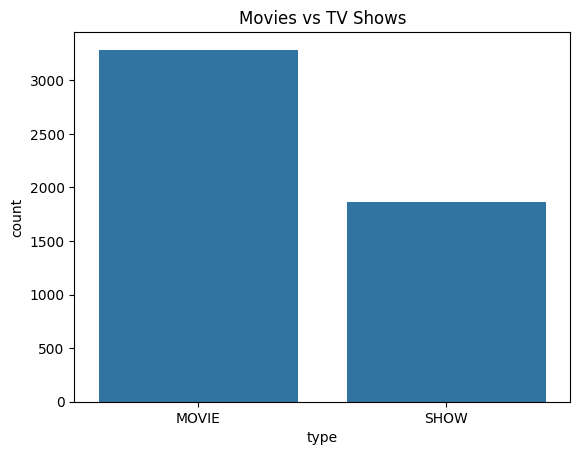

In [45]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

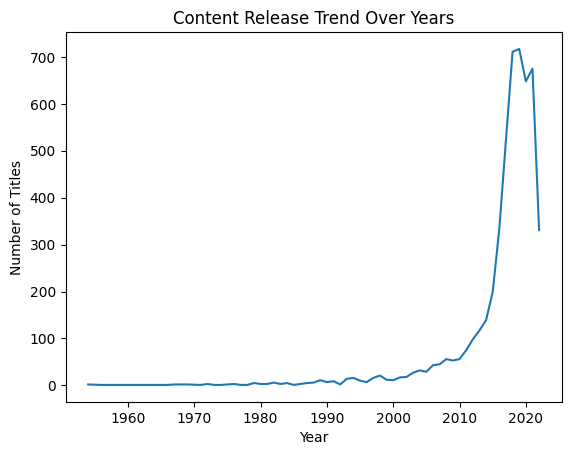

In [46]:
df['release_year'].value_counts().sort_index().plot()

plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

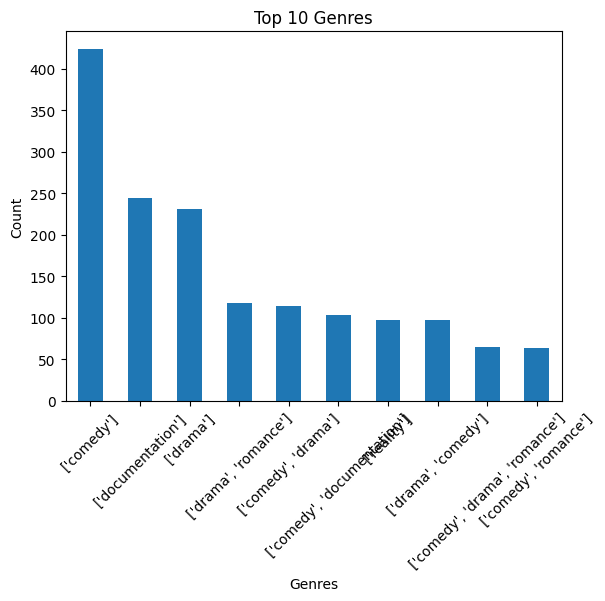

In [47]:
df['genres'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

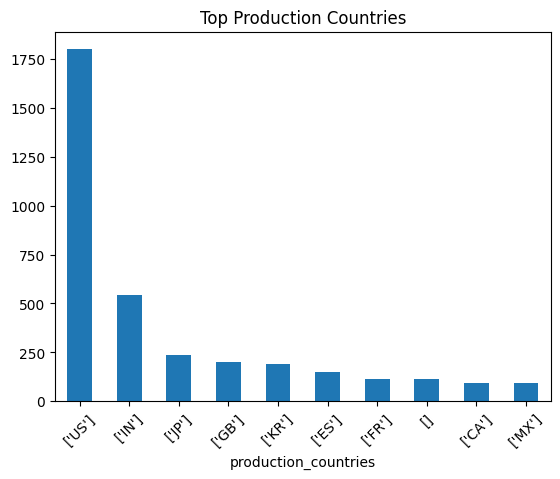

In [48]:
df['production_countries'].value_counts().head(10).plot(kind='bar')

plt.title("Top Production Countries")
plt.xticks(rotation=45)
plt.show()

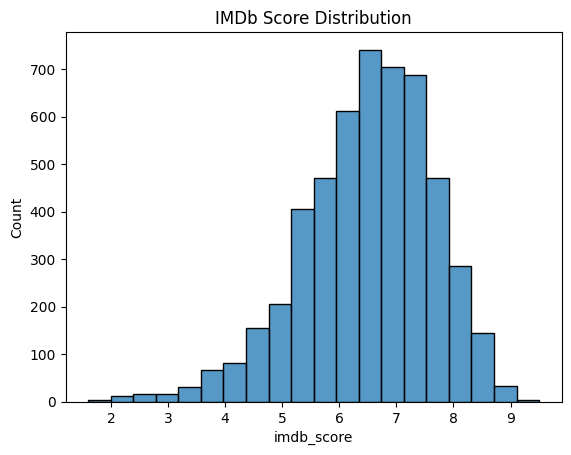

In [49]:
sns.histplot(df['imdb_score'], bins=20)

plt.title("IMDb Score Distribution")
plt.show()

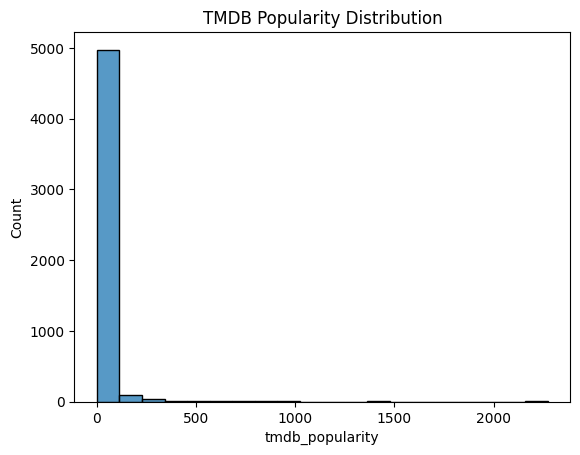

In [50]:
sns.histplot(df['tmdb_popularity'], bins=20)

plt.title("TMDB Popularity Distribution")
plt.show()

In [51]:
features = ['release_year', 'runtime', 'tmdb_popularity', 'tmdb_score']
target = 'imdb_score'

X = df[features]
y = df[target]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.8557403369188707
R2 Score: 0.34151469419568403
